데이터 로드 성공!


C:\Users\user\AppData\Local\Temp\ipykernel_17672\1714278806.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=intent_counts.values, y=intent_counts.index, palette=colors)


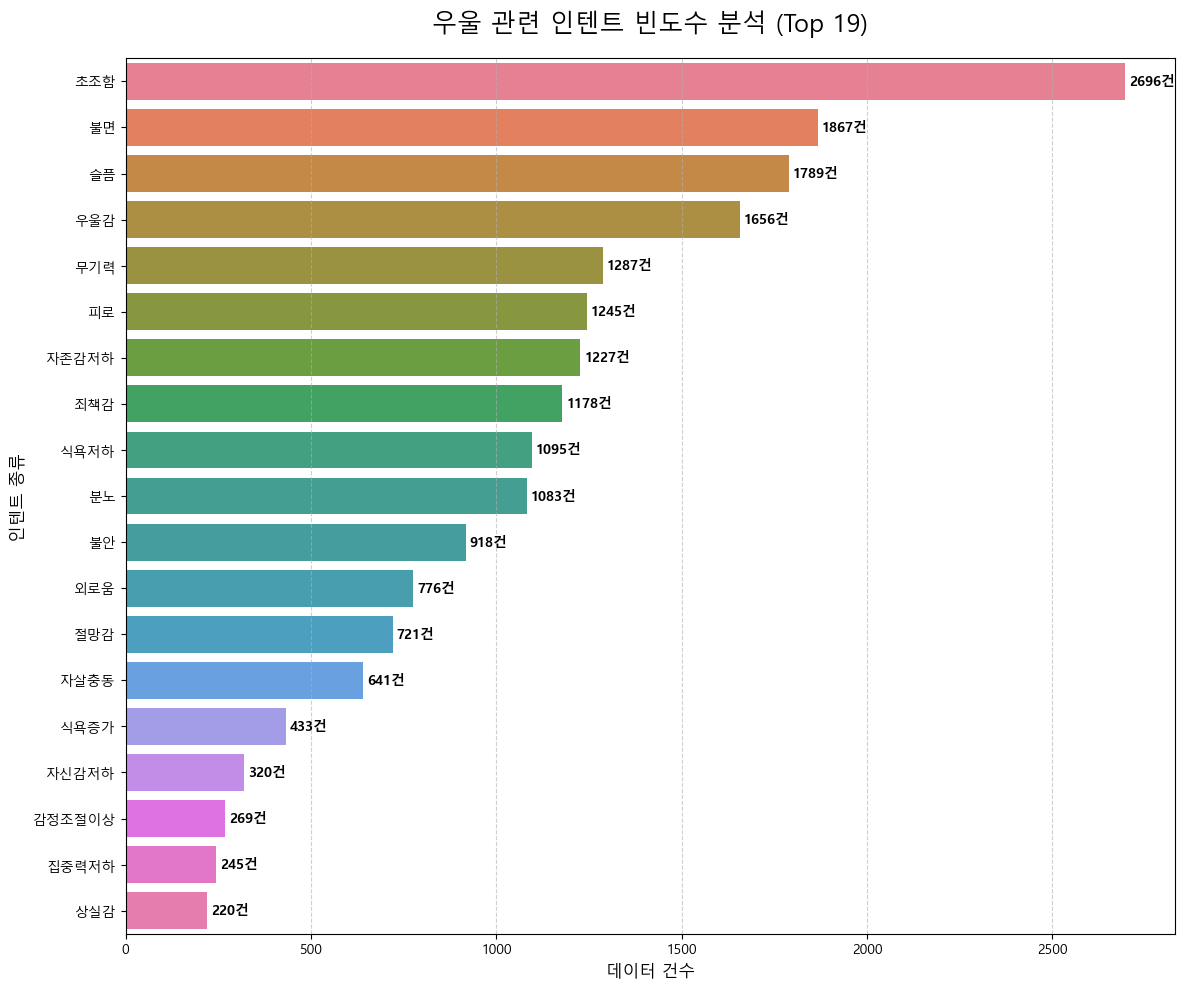

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform

# 1. 한글 폰트 설정 (운영체제별 대응)
if platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows': # Windows
    plt.rc('font', family='Malgun Gothic')
else: # Linux (Ubuntu 등)
    plt.rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 2. 데이터 불러오기
try:
    df = pd.read_csv('cleaned_wellness.csv')
    print("데이터 로드 성공!")
except FileNotFoundError:
    print("파일을 찾을 수 없습니다. 파일명을 확인해주세요.")

# 3. 인텐트별 빈도수 계산 및 정렬
intent_counts = df['intent'].value_counts().sort_values(ascending=False)

# 4. 가로 막대 그래프 시각화
plt.figure(figsize=(12, 10)) # 19개 항목이므로 세로 길이를 넉넉히 설정
colors = sns.color_palette("husl", len(intent_counts)) # 다양한 색상 적용

# 막대 그래프 그리기
barplot = sns.barplot(x=intent_counts.values, y=intent_counts.index, palette=colors)

# 각 막대 끝에 숫자 표시 (가독성 향상)
for i, v in enumerate(intent_counts.values):
    plt.text(v + 10, i, f'{v}건', va='center', fontsize=12, fontweight='bold')

# 차트 꾸미기
plt.title('우울 관련 인텐트 빈도수 분석', fontsize=18, pad=20)
plt.xlabel('데이터 건수', fontsize=12)
plt.ylabel('인텐트 종류', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6) # x축 가이드라인 추가
plt.tight_layout()

# 5. 결과 저장 및 출력
plt.savefig('intent_analysis_result.png', dpi=300)
plt.show()

데이터 로드 성공!


C:\Users\user\AppData\Local\Temp\ipykernel_17672\2653077346.py:31: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




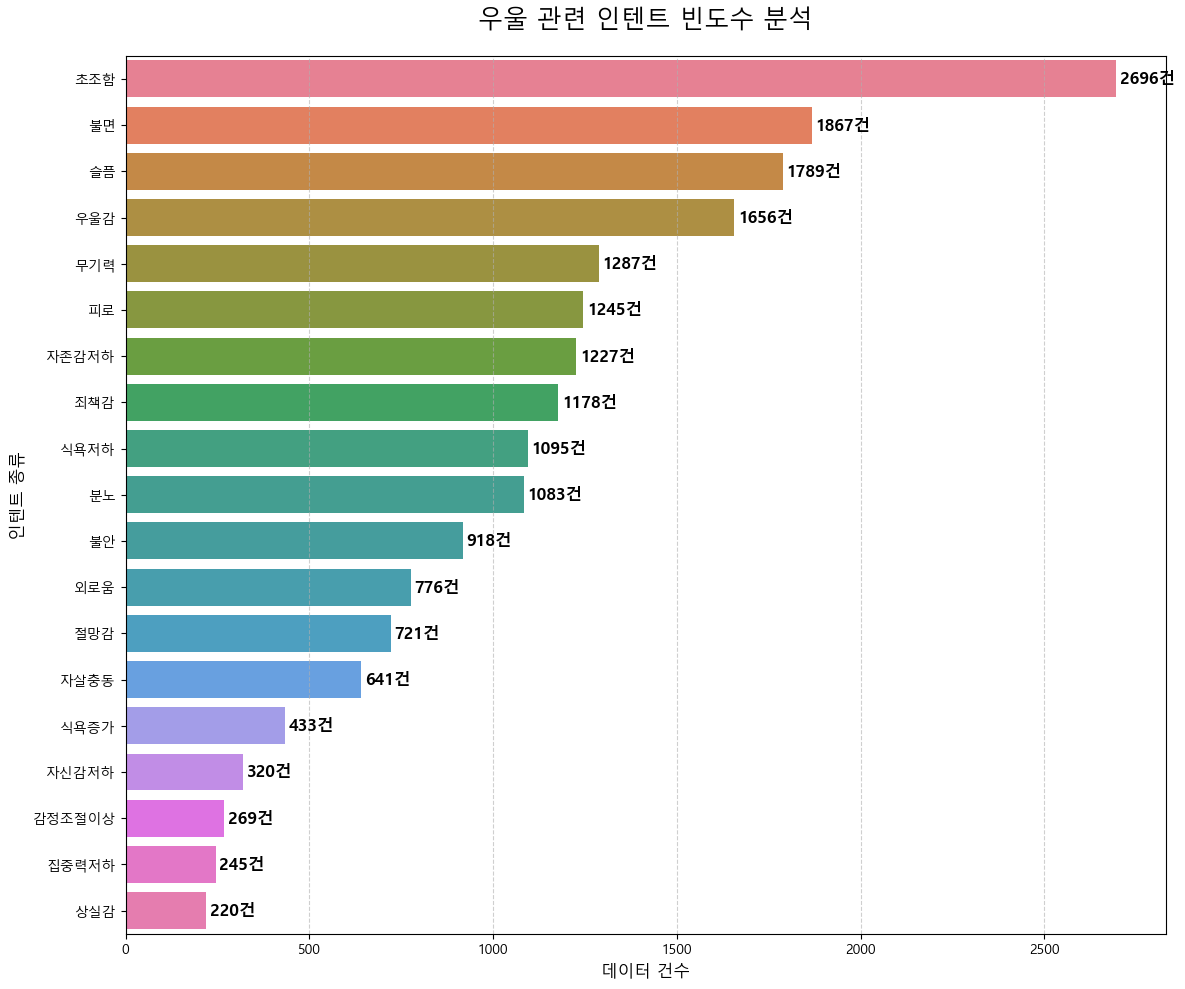

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform

# 1. 한글 폰트 설정 (운영체제별 대응)
if platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows': # Windows
    plt.rc('font', family='Malgun Gothic')
else: # Linux (Ubuntu 등)
    plt.rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 2. 데이터 불러오기
try:
    df = pd.read_csv('cleaned_wellness.csv')
    print("데이터 로드 성공!")
except FileNotFoundError:
    print("파일을 찾을 수 없습니다. 파일명을 확인해주세요.")

# 3. 인텐트별 빈도수 계산 및 정렬
intent_counts = df['intent'].value_counts().sort_values(ascending=False)

# 4. 가로 막대 그래프 시각화
plt.figure(figsize=(12, 10)) # 19개 항목이므로 세로 길이를 넉넉히 설정
colors = sns.color_palette("husl", len(intent_counts)) # 다양한 색상 적용

# 막대 그래프 그리기
barplot = sns.barplot(x=intent_counts.values, y=intent_counts.index, palette=colors)

# 각 막대 끝에 숫자 표시 (가독성 향상)
for i, v in enumerate(intent_counts.values):
    plt.text(v + 10, i, f'{v}건', va='center', fontsize=12, fontweight='bold')

# 차트 꾸미기
plt.title('우울 관련 인텐트 빈도수 분석', fontsize=18, pad=20)
plt.xlabel('데이터 건수', fontsize=12)
plt.ylabel('인텐트 종류', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6) # x축 가이드라인 추가
plt.tight_layout()

# 5. 결과 저장 및 출력
plt.savefig('intent_analysis_result.png', dpi=300)
plt.show()

In [2]:
import pandas as pd
import plotly.express as px

# 데이터 불러오기
df = pd.read_csv('cleaned_wellness.csv')
intent_counts = df['intent'].value_counts().reset_index()
intent_counts.columns = ['intent', 'count']

# 트리맵 시각화
fig = px.treemap(intent_counts, 
                 path=['intent'], 
                 values='count',
                 color='count',
                 color_continuous_scale='RdBu',
                 title='우울 인텐트 비중 분석 (Treemap)')

fig.update_traces(textinfo="label+value+percent root")
fig.show()

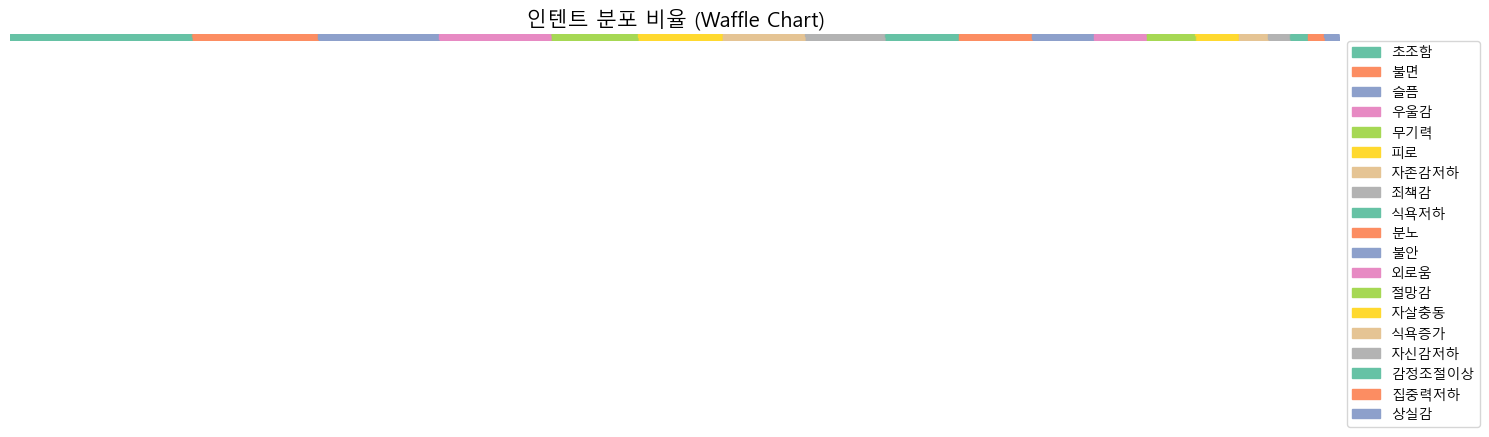

In [4]:
# 설치 필요: pip install pywaffle
import pandas as pd
import matplotlib.pyplot as plt
from pywaffle import Waffle

df = pd.read_csv('cleaned_wellness.csv')
intent_counts = df['intent'].value_counts()

# 너무 많은 항목은 가독성을 해치므로 상위 10개 + 기타로 묶는 것도 방법입니다.
# 여기서는 19개 전체를 표현합니다.
fig = plt.figure(
    FigureClass=Waffle,
    rows=10, 
    values=intent_counts.to_dict(),
    legend={'loc': 'upper left', 'bbox_to_anchor': (1, 1)},
    figsize=(15, 8),
    font_size=12
)

plt.title("인텐트 분포 비율 (Waffle Chart)", fontsize=15)
plt.show()

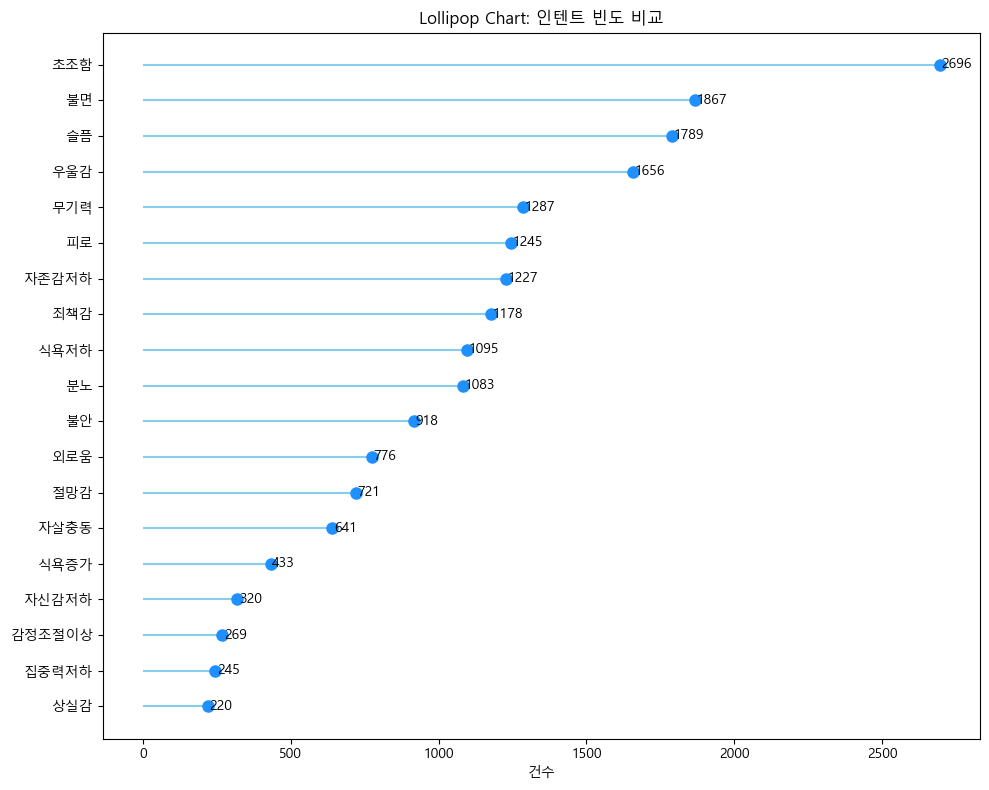

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 설정 필요 (위의 코드 참고)

df = pd.read_csv('cleaned_wellness.csv')
counts = df['intent'].value_counts().sort_values()

plt.figure(figsize=(10, 8))
plt.hlines(y=counts.index, xmin=0, xmax=counts.values, color='skyblue')
plt.plot(counts.values, counts.index, "o", markersize=8, color='dodgerblue')

for i, v in enumerate(counts.values):
    plt.text(v + 5, i, f'{v}', va='center')

plt.title("Lollipop Chart: 인텐트 빈도 비교")
plt.xlabel("건수")
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
import plotly.express as px

df = pd.read_csv('cleaned_wellness.csv')
intent_counts = df['intent'].value_counts().reset_index()
intent_counts.columns = ['intent', 'count']

# 선버스트 차트
fig = px.sunburst(intent_counts, 
                  path=['intent'], 
                  values='count',
                  color='count', 
                  color_continuous_scale='Blues',
                  title='인텐트 비율 분석 (Sunburst)')

fig.update_traces(textinfo="label+percent root")
fig.show()

In [7]:
# 아이시클 플롯 (옆으로 뻗어나가는 구조)
fig = px.icicle(intent_counts, 
                path=['intent'], 
                values='count',
                color='count',
                color_continuous_scale='Viridis',
                title='인텐트 비율 분석 (Icicle)')

fig.update_traces(textinfo="label+value")
fig.show()

In [8]:
# Plotly에서는 scatter를 활용해 버블 차트를 구현합니다.
fig = px.scatter(intent_counts, 
                 x='intent', 
                 y=[1]*len(intent_counts), # 일렬 배치를 위해 y값을 고정
                 size='count', 
                 color='intent',
                 text='intent',
                 size_max=60,
                 title='인텐트 크기 비교 (Bubble Chart)')

fig.update_layout(yaxis={'visible': False}, height=400)
fig.show()